# Practice Question 28: Cross-Validation and ROC Curve

**Anna Castillo**

## Question 1: Cross-validation from scratch

In [6]:
import numpy as np
import pandas as pd
from sklearn.base import clone                 #only makes an unfitted copy of the model
from sklearn.metrics import accuracy_score     #accuracy metric (allowed by the hints)

In [7]:
def cross_validation(X, y, k, model, random_state=None, verbose=True):
    #X and y are pandas objects with the same 0..m-1 index
    X = pd.DataFrame(X).reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    m = len(X)

    if len(y) != m:
        raise ValueError("X and y must have the same number of observations.")
    if not isinstance(k, (int, np.integer)) or k < 2 or k > m:
        raise ValueError("k must be an integer between 2 and " + str(m))

    #step 1: random split into k partitions
    rng = np.random.default_rng(random_state)
    shuffled = rng.permutation(m)              #random order of row positions
    fold_size = m // k                         #largest whole number of rows per fold
    partitions = []
    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size if i < k - 1 else m   # last fold takes the remainder
        partitions.append(shuffled[start:end])

    #steps 2-4: k iterations of fit / predict / score
    scores = []
    for i in range(k):
        test_idx = partitions[i]
        train_idx = np.concatenate([partitions[j] for j in range(k) if j != i])

        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

        fold_model = clone(model)              #fresh and unfitted copy each iteration
        fold_model.fit(X_train, y_train)
        predictions = fold_model.predict(X_test)

        acc = accuracy_score(y_test, predictions)
        scores.append(acc)
        if verbose:
            print("Fold", i + 1, "- train size:", len(train_idx), "- test size:", len(test_idx), "- accuracy:", round(acc, 4))

    #output of average accuracy
    cv_accuracy = sum(scores) / len(scores)
    if verbose:
        print()
        print("Cross-validation accuracy:", round(cv_accuracy, 4))
    return cv_accuracy

### Test the function (two different models, including a k that does not divide the data evenly)

In [5]:
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target          #569 observations

print("Decision tree, k = 5 (569 is not divisible by 5 - last fold gets the extra rows)")
dt_model = tree.DecisionTreeClassifier(random_state=1)
cross_validation(X, y, 5, dt_model, random_state=42)

Decision tree, k = 5 (569 is not divisible by 5 - last fold gets the extra rows)
Fold  1: train =  456, test = 113, accuracy = 0.9646
Fold  2: train =  456, test = 113, accuracy = 0.9292
Fold  3: train =  456, test = 113, accuracy = 0.9115
Fold  4: train =  456, test = 113, accuracy = 0.9292
Fold  5: train =  452, test = 117, accuracy = 0.9231

Cross-validation accuracy (5-fold): 0.9315


0.9315180394826413

In [8]:
print("Logistic regression, k = 10")
lr_model = LogisticRegression(max_iter=5000)
cross_validation(X, y, 10, lr_model, random_state=42)

Logistic regression, k = 10
Fold 1 - train size: 513 - test size: 56 - accuracy: 0.9821
Fold 2 - train size: 513 - test size: 56 - accuracy: 0.9464
Fold 3 - train size: 513 - test size: 56 - accuracy: 0.9821
Fold 4 - train size: 513 - test size: 56 - accuracy: 0.9643
Fold 5 - train size: 513 - test size: 56 - accuracy: 0.9286
Fold 6 - train size: 513 - test size: 56 - accuracy: 0.9464
Fold 7 - train size: 513 - test size: 56 - accuracy: 0.9464
Fold 8 - train size: 513 - test size: 56 - accuracy: 0.9821
Fold 9 - train size: 513 - test size: 56 - accuracy: 0.9464
Fold 10 - train size: 504 - test size: 65 - accuracy: 0.9385

Cross-validation accuracy: 0.9563


0.9563461538461538

In [9]:
#partitions are disjoint and cover every observation exactly once
m, k = len(X), 7
rng = np.random.default_rng(0)
shuffled = rng.permutation(m)
fs = m // k
parts = [shuffled[i*fs:(i+1)*fs] if i < k-1 else shuffled[i*fs:] for i in range(k)]
print("fold sizes:", [len(p) for p in parts])
print("all rows used exactly once:", sorted(np.concatenate(parts)) == list(range(m)))

fold sizes: [81, 81, 81, 81, 81, 81, 83]
all rows used exactly once: True


## Question 2: ROC curve from scratch

In [10]:
import csv
import matplotlib.pyplot as plt

#load data (plain Python)
probs, labels = [], []
with open("roc_curve_data.csv", newline="") as f:
    for row in csv.DictReader(f):
        probs.append(float(row["Pred_Prob_1"]))
        labels.append(int(row["Actual_Label"]))

print("observations:", len(probs))
print("actual positives (1):", sum(labels), "| actual negatives (0):", len(labels) - sum(labels))

observations: 820
actual positives (1): 657 | actual negatives (0): 163


In [11]:
#confusion-matrix counts, TPR and FPR for each cutoff
cutoffs = [i / 1000 for i in range(0, 1001)]      # 0.0, 0.001, ..., 1.0

tpr_list, fpr_list = [], []
for cutoff in cutoffs:
    TP = FN = FP = TN = 0
    for p, actual in zip(probs, labels):
        predicted = 1 if p >= cutoff else 0
        if actual == 1 and predicted == 1:
            TP += 1
        elif actual == 1 and predicted == 0:
            FN += 1
        elif actual == 0 and predicted == 1:
            FP += 1
        else:
            TN += 1
    tpr_list.append(TP / (TP + FN))                #True Positive Rate = TP / (TP + FN)
    fpr_list.append(FP / (FP + TN))                #False Positive Rate = FP / (FP + TN)

#quick look at three cutoffs
for c in (0.0, 0.5, 1.0):
    i = int(round(c * 1000))
    print("cutoff", c, ": FPR =", round(fpr_list[i], 4), ", TPR =", round(tpr_list[i], 4))

cutoff 0.0 : FPR = 1.0 , TPR = 1.0
cutoff 0.5 : FPR = 0.6748 , TPR = 0.9878
cutoff 1.0 : FPR = 0.0 , TPR = 0.0


In [12]:
#AUC with the trapezoid rule (points run from FPR = 1 down to FPR = 0)
auc = 0.0
for i in range(len(cutoffs) - 1):
    width = fpr_list[i] - fpr_list[i + 1]
    height = (tpr_list[i] + tpr_list[i + 1]) / 2
    auc += width * height
print("AUC (from scratch) =", round(auc, 4))

AUC (from scratch) = 0.7998


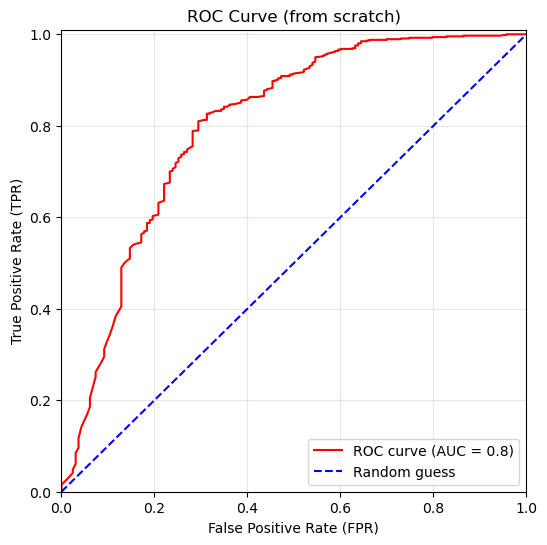

In [13]:
#plot the ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr_list, tpr_list, color="red", label="ROC curve (AUC = " + str(round(auc, 3)) + ")")
plt.plot([0, 1], [0, 1], color="blue", linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (from scratch)")
plt.xlim(0, 1); plt.ylim(0, 1.01)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.show()

### Correctness check (hint 5)
Comparison with scikit-learn's `RocCurveDisplay.from_predictions`.

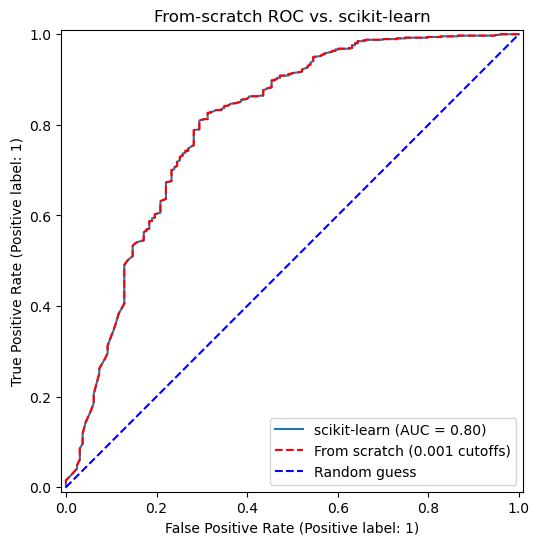

AUC from scratch : 0.7998
AUC scikit-learn : 0.7998


In [14]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(labels, probs, name="scikit-learn", ax=ax)
ax.plot(fpr_list, tpr_list, color="red", linestyle="--", label="From scratch (0.001 cutoffs)")
ax.plot([0, 1], [0, 1], "b--", label="Random guess")
ax.legend(loc="lower right")
ax.set_title("From-scratch ROC vs. scikit-learn")
plt.show()

print("AUC from scratch :", round(auc, 4))
print("AUC scikit-learn :", round(roc_auc_score(labels, probs), 4))